# Clase 1 — RAG Simple

## Retrieval-Augmented Generation: fundamentos

**Objetivos de la clase:**
- Entender por qué los LLMs por sí solos no bastan (alucinaciones, conocimiento desactualizado).
- Construir un pipeline RAG completo: *chunking → embeddings → vector store → retrieval → generación*.
- Comparar respuestas **con** y **sin** RAG sobre el mismo documento.
- Experimentar de forma interactiva con los parámetros clave del pipeline (tamaño de chunk, k, embeddings).

📎 Material de referencia: `Clase_8_RAG.pdf` (slides 1 a 6).

Este notebook es el primero de una serie de 4 clases: **RAG Simple → RAG Avanzado → Evaluación de RAG → GraphRAG**. En cada clase construiremos sobre lo aprendido en la anterior.

## 1. ¿Por qué RAG? Las limitaciones de los LLMs

Los LLMs entrenados de forma estática presentan varios problemas (slide "Limitaciones de los LLMs"):

- **Alucinaciones**: respuestas inventadas con total seguridad.
- **Información desactualizada**: el conocimiento del modelo queda fijo en su fecha de entrenamiento.
- **Baja eficiencia al parametrizar conocimiento**: reentrenar el modelo para cada dominio es costoso.
- **Falta de profundidad en dominios especializados**.
- **Debilidad inferencial** (razonamiento limitado sobre hechos que no vio explícitamente).

**RAG (Retrieval-Augmented Generation)** ataca estos problemas separando dos cosas: *qué sabe el modelo* de *qué información tiene disponible en el momento de responder*. En vez de reentrenar, le damos al LLM acceso a una base de conocimiento externa y dejamos que **recupere** los fragmentos relevantes antes de **generar** la respuesta.

In [1]:
# Instalar los paquetes necesarios
!pip install -q wikipedia python-dotenv==1.1.0 \
    langchain-community==0.3.25 langchain_openai==0.3.23 faiss-cpu==1.11.0 \
    langchain-huggingface sentence-transformers scikit-learn ipywidgets tqdm

# Evitar que transformers intente usar TensorFlow/Keras 3 (no lo necesitamos: los modelos de
# HuggingFace que usamos corren en PyTorch). Esto debe ejecutarse ANTES de importar
# transformers/sentence_transformers por primera vez — si ya los importaste en esta sesión,
# reinicia el kernel/runtime para que tome efecto.
import os
os.environ["USE_TF"] = "0"
os.environ["TRANSFORMERS_NO_TF"] = "1"


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.4/65.4 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.3/31.3 MB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 461.3/461.3 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.0/363.0 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.6/948.6 kB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 83.8 MB/s eta 0:00:00
ERROR: pip's depe

In [ ]:
import os

try:
    from google.colab import userdata
    from google.colab.userdata import SecretNotFoundError
except ModuleNotFoundError:
    userdata = None
    SecretNotFoundError = type('SecretNotFoundError', (Exception,), {})


def obtener_secret(nombre, prompt_text=None):
    if userdata is not None:
        try:
            valor = userdata.get(nombre)
            if valor:
                return valor
        except SecretNotFoundError:
            # Secret not found in Colab userdata, proceed to environment variables
            pass

    valor = os.getenv(nombre)
    if valor:
        return valor

    return input(prompt_text or f"Ingresa {nombre}: ")

# OpenRouter se usa para el LLM (generación, LLM-as-judge, etc.) — crea tu key en openrouter.ai/keys
os.environ["OPENROUTER_API_KEY"] = obtener_secret("OPENROUTER_API_KEY", "OpenRouter API key: ")
# OpenAI se mantiene SOLO para los embeddings: OpenRouter no expone un endpoint de embeddings
os.environ["OPENAI_API_KEY"] = obtener_secret("OPENAI_API_KEY_DIPLOMADO", "OpenAI API key (para embeddings): ")

OPENROUTER_BASE_URL = "https://openrouter.ai/api/v1"
OPENROUTER_MODEL = "deepseek/deepseek-v4-flash"  # cámbialo por cualquier modelo de openrouter.ai/models

### Descargar el documento de trabajo

Durante las clases 1, 2 y 3 vamos a trabajar sobre el **mismo documento**: el artículo de Wikipedia en español [**"Cambio climático en Chile"**](https://es.wikipedia.org/wiki/Cambio_climático_en_Chile). Así comparamos de forma justa las técnicas que vayamos incorporando clase a clase, sobre un caso local y en español.

In [4]:
from langchain_community.document_loaders import WikipediaLoader

WIKI_QUERY = "Cambio climático en Chile"

documento = WikipediaLoader(
    query=WIKI_QUERY, lang="es", load_max_docs=1, doc_content_chars_max=40000
).load()

print(f"Artículo cargado: '{documento[0].metadata.get('title')}' ({len(documento[0].page_content)} caracteres)")


Artículo cargado: 'Cambio climático en Chile' (36503 caracteres)


## 2. Una pregunta, sin contexto

Antes de construir nada, probemos qué responde el LLM **sin ningún documento de por medio** — solo con su conocimiento general. Esto replica el lado izquierdo del diagrama "RAG: Integrando Recuperación y Generación" de la slide 3.

In [5]:
from langchain_openai import ChatOpenAI

def crear_llm(model=None, **kwargs):
    """ChatOpenAI apuntando a OpenRouter en vez de a la API de OpenAI directamente."""
    return ChatOpenAI(
        model=model or OPENROUTER_MODEL,
        base_url=OPENROUTER_BASE_URL,
        api_key=os.environ["OPENROUTER_API_KEY"],
        **kwargs,
    )

llm = crear_llm(temperature=0)

pregunta_ejemplo = "¿cuáles son los principales efectos del cambio climático en Chile y qué evidencia reciente los respalda?"
respuesta_sin_contexto = llm.invoke(pregunta_ejemplo).content
print(respuesta_sin_contexto)


Claro, aquí tienes una respuesta estructurada sobre los principales efectos del cambio climático en Chile, respaldada por evidencia reciente (actualizada a 2025).

### Principales efectos del cambio climático en Chile

Chile es uno de los países más vulnerables al cambio climático debido a su geografía diversa (desiertos, glaciares, costas, bosques y la Antártica). Los efectos se manifiestan de manera diferenciada en cada región.

#### 1. **Megasequía y escasez hídrica**
- **Efecto:** Reducción drástica de precipitaciones, especialmente en la zona central (desde Coquimbo hasta La Araucanía). Esto ha provocado una crisis hídrica que afecta el consumo humano, la agricultura y la generación hidroeléctrica.
- **Evidencia reciente:**
  - El **Centro de Ciencia del Clima y la Resiliencia (CR)2** reportó que la megasequía que comenzó en 2010 es la más prolongada en 1.000 años, con una disminución de lluvias del 20-30% en la zona central.
  - En 2024, la **Dirección General de Aguas (DGA)** co

Nota cómo el modelo responde en términos generales — no tiene acceso al documento específico que queremos consultar. Vamos a resolver esto.

## 3. Chunking: dividir el documento en fragmentos

El primer paso de RAG (slide "Componentes de RAG: Preprocesamiento") es transformar el PDF en fragmentos ("chunks") manejables. Dos parámetros clave:

- **`chunk_size`**: cuántos caracteres tiene cada fragmento.
- **`chunk_overlap`**: cuánto se solapan fragmentos consecutivos (para no cortar ideas a la mitad).

Usa el widget de abajo para ver cómo cambian la cantidad de chunks y su contenido al mover los sliders.

In [6]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

def dividir_en_chunks(documento, chunk_size=1000, chunk_overlap=200):
    """Divide el artículo ya descargado en chunks de texto."""
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size, chunk_overlap=chunk_overlap, length_function=len
    )
    chunks = splitter.split_documents(documento)
    for c in chunks:
        c.page_content = c.page_content.replace('\t', ' ')
    return chunks


In [7]:
import ipywidgets as widgets
import textwrap

@widgets.interact(
    chunk_size=widgets.IntSlider(value=500, min=100, max=2000, step=100, description="chunk_size"),
    chunk_overlap=widgets.IntSlider(value=100, min=0, max=500, step=50, description="overlap"),
)
def explorar_chunking(chunk_size, chunk_overlap):
    chunks = dividir_en_chunks(documento, chunk_size, chunk_overlap)
    print(f"Número de chunks generados: {len(chunks)}\n")
    print("\n --- Primer chunk ---")
    print(textwrap.fill(chunks[0].page_content, width=90))
    print("\n --- Segundo chunk ---")
    print(textwrap.fill(chunks[1].page_content, width=90))

interactive(children=(IntSlider(value=500, description='chunk_size', max=2000, min=100, step=100), IntSlider(v…

In [8]:
# Fijamos una configuración para el resto de la clase
CHUNK_SIZE = 1000
CHUNK_OVERLAP = 200
chunks = dividir_en_chunks(documento, CHUNK_SIZE, CHUNK_OVERLAP)
for i, c in enumerate(chunks):
    c.metadata["chunk_id"] = i  # nos sirve más adelante para ubicar los chunks en el gráfico de embeddings
print(f"Usaremos {len(chunks)} chunks (chunk_size={CHUNK_SIZE}, overlap={CHUNK_OVERLAP}) para el resto de la clase.")

Usaremos 63 chunks (chunk_size=1000, overlap=200) para el resto de la clase.


## 4. Embeddings + Vector Store (FAISS)

Cada chunk se convierte en un vector numérico (embedding) que captura su significado semántico. Guardamos todos los vectores en una base de datos vectorial ([FAISS](https://engineering.fb.com/2017/03/29/data-infrastructure/faiss-a-library-for-efficient-similarity-search/)) que permite buscar por similitud de forma eficiente (slide "Componentes de RAG: Preprocesamiento" y "Retrieval").

In [9]:
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS

embeddings = OpenAIEmbeddings(model="text-embedding-3-large")
vectorstore = FAISS.from_documents(chunks, embeddings)
print("Vector store creado con", vectorstore.index.ntotal, "vectores.")

Vector store creado con 63 vectores.


## 5. Retriever interactivo

El retriever convierte tu pregunta en un embedding y busca los `k` chunks más parecidos por similitud coseno. Prueba distintas preguntas y valores de `k`.

In [10]:
import textwrap

@widgets.interact_manual(
    pregunta=widgets.Textarea(
        value="¿Qué es la megasequía y qué regiones de Chile ha afectado?",
        description="Pregunta",
        layout=widgets.Layout(width="100%", height="60px"),
    ),
    k=widgets.IntSlider(value=3, min=1, max=8, description="k"),
)
def probar_retriever(pregunta, k):
    retriever = vectorstore.as_retriever(search_kwargs={"k": k})
    docs = retriever.invoke(pregunta)
    for i, d in enumerate(docs):
        print(f"--- Chunk {i + 1} ---")
        print(textwrap.fill(d.page_content[:400], width=90))
        print()

interactive(children=(Textarea(value='¿Qué es la megasequía y qué regiones de Chile ha afectado?', description…

## 6. Generación: construir el prompt enriquecido

Con los chunks recuperados armamos un **prompt enriquecido** (contexto + pregunta) y se lo pasamos al LLM (slide "Componentes de RAG: Generación"). Comparemos ahora, sobre la misma pregunta, la respuesta **sin RAG** vs **con RAG**.

In [11]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

rag_prompt = ChatPromptTemplate.from_messages([
    ("system", "Eres un asistente que responde ÚNICAMENTE usando el contexto entregado. "
               "Si la respuesta no está en el contexto, dilo explícitamente."),
    ("human", "Contexto:\n{contexto}\n\nPregunta: {pregunta}"),
])

rag_chain = rag_prompt | llm | StrOutputParser()

def responder_con_rag(pregunta, k=3):
    docs = vectorstore.as_retriever(search_kwargs={"k": k}).invoke(pregunta)
    contexto = "\n\n".join(d.page_content for d in docs)
    return rag_chain.invoke({"contexto": contexto, "pregunta": pregunta})

In [12]:
from IPython.display import HTML, display
import html


def mostrar_respuesta_etiquetada(titulo, texto):
    texto_html = html.escape(texto).replace("\n", "<br>")
    display(
        HTML(
            f"<div style='font-size: 1.15em; line-height: 1.5; white-space: pre-wrap;'><b>{titulo}</b><br>{texto_html}</div>"
        )
    )

@widgets.interact_manual(
    pregunta=widgets.Textarea(
        value="¿Qué es la megasequía y qué regiones de Chile ha afectado?",
        description="Pregunta",
        layout=widgets.Layout(width="100%", height="40px"),
    )
)
def comparar_con_sin_rag(pregunta):
    mostrar_respuesta_etiquetada("SIN RAG", llm.invoke(pregunta).content)
    display(HTML("<hr>"))
    mostrar_respuesta_etiquetada("CON RAG", responder_con_rag(pregunta))

interactive(children=(Textarea(value='¿Qué es la megasequía y qué regiones de Chile ha afectado?', description…

## 7. Bonus: embeddings open-source vs OpenAI

No siempre queremos (o podemos) pagar por una API de embeddings. Comparemos `OpenAIEmbeddings` con un modelo open-source liviano de HuggingFace que corre en CPU sin costo.

In [20]:
from langchain_huggingface import HuggingFaceEmbeddings
import os

# Set HF_TOKEN using the existing obtener_secret function
os.environ["HF_TOKEN"] = obtener_secret("HF_TOKEN", "HuggingFace API token (optional, for higher rate limits): ")

# Un solo llamado con todos los chunks: sentence-transformers los procesa en batch internamente,
# lo que es mucho más rápido que codificar chunk por chunk. show_progress_bar te deja ver el avance.
hf_embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    encode_kwargs={"batch_size": 32},
    show_progress=False,
)
vectorstore_hf = FAISS.from_documents(chunks, hf_embeddings)
print("Vector store open-source creado con", vectorstore_hf.index.ntotal, "vectores.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Vector store open-source creado con 63 vectores.


In [21]:
@widgets.interact_manual(
    pregunta=widgets.Textarea(
        value="¿Qué instituciones lideran la política de cambio climático en Chile?",
        description="Pregunta",
        layout=widgets.Layout(width="100%", height="60px"),
    )
)
def comparar_embeddings(pregunta):
    print("--- OpenAI (text-embedding-3-large) ---")
    for d in vectorstore.as_retriever(search_kwargs={"k": 2}).invoke(pregunta):
        print("*", d.page_content[:200].replace("\n", " "), "...\n")
    print("--- HuggingFace (all-MiniLM-L6-v2, gratis) ---")
    for d in vectorstore_hf.as_retriever(search_kwargs={"k": 2}).invoke(pregunta):
        print("*", d.page_content[:200].replace("\n", " "), "...\n")

interactive(children=(Textarea(value='¿Qué instituciones lideran la política de cambio climático en Chile?', d…

## 8. Visualizar los embeddings en 2D

Los embeddings viven en un espacio de cientos de dimensiones. Proyectándolos a 2D (con PCA) podemos ver de forma intuitiva qué tan cerca queda una pregunta de los chunks más relevantes.

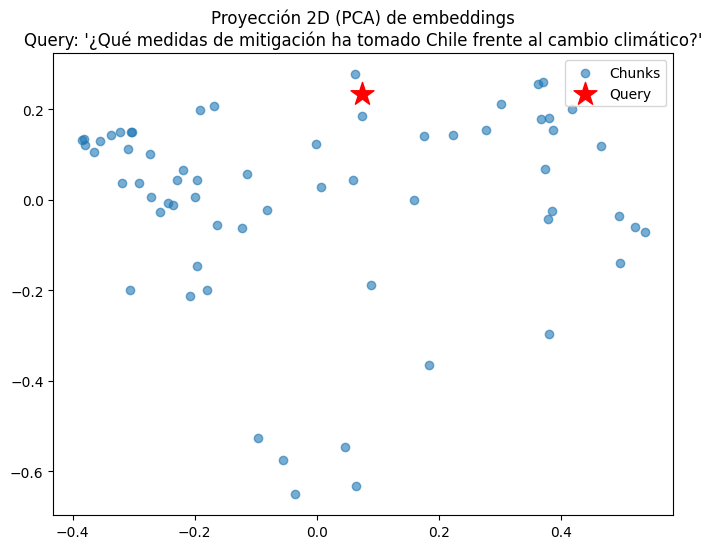

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def visualizar_embeddings(query, vectorstore, embeddings_model):
    n = vectorstore.index.ntotal
    vecs = np.array([vectorstore.index.reconstruct(i) for i in range(n)])
    query_vec = np.array(embeddings_model.embed_query(query))
    todos = np.vstack([vecs, query_vec])

    proyeccion = PCA(n_components=2).fit_transform(todos)

    plt.figure(figsize=(8, 6))
    plt.scatter(proyeccion[:-1, 0], proyeccion[:-1, 1], alpha=0.6, label="Chunks")
    plt.scatter(proyeccion[-1, 0], proyeccion[-1, 1], color="red", marker="*", s=300, label="Query")
    plt.legend()
    plt.title(f"Proyección 2D (PCA) de embeddings\nQuery: '{query}'")
    plt.show()

visualizar_embeddings("¿Qué medidas de mitigación ha tomado Chile frente al cambio climático?", vectorstore, embeddings)

## Ejercicios propuestos

1. **Explorando el tamaño de los chunks**
   - Vuelve al widget de la sección 3 y prueba valores extremos (`chunk_size=200` y `chunk_size=2000`).
   - ¿Qué le pasa a la calidad de las respuestas cuando los chunks son muy pequeños o muy grandes?

2. **Preguntas fuera del documento**
   - Prueba con una pregunta que el documento claramente no responde (por ejemplo, sobre otro tema).
   - ¿El sistema "con RAG" reconoce que no tiene la información, o alucina igual?

3. **Comparación de embeddings**
   - Usa el widget de la sección 7 con 3-4 preguntas distintas.
   - ¿En qué casos el embedding open-source recupera chunks distintos a los de OpenAI? ¿Cuál te parece mejor?

## Próximo Tutorial

Este pipeline es la versión **naive** de RAG: solo usa similitud vectorial, recupera un `k` fijo, y no filtra ni reordena resultados. En la **Clase 2 — RAG Avanzado** vamos a mejorar tanto el *antes* (pre-retrieval: mejor chunking) como el *después* (post-retrieval: fusion retrieval con BM25, reranking, filtrado de relevancia) de la recuperación.